In [1]:
import sys
from pathlib import Path
import yaml
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -- Data Source -------------------------------------------------------------
# "local" = use existing CSV/Deriv data, "binance" = fetch live from Binance
DATA_SOURCE = "binance"

# Binance settings (only used when DATA_SOURCE == "binance")
BINANCE_SYMBOL   = "BTCUSDT"
BINANCE_INTERVAL = "1h"

# Single source of truth for all symbol labels across prints/plots.
SYMBOL_LABEL = BINANCE_SYMBOL

# -- Timeframes to plot ------------------------------------------------------
# For Binance: any subset of ["1m", "5m", "15m", "1h", "4h", "1d"]
# For local: list the timeframe strings your local data supports
TIMEFRAMES_TO_PLOT = ["5m", "15m", "1h", "4h"]

# -- Filter 1: Parent-relative impulse size ----------------------------------
# Rejects impulses smaller than X% of the full detection window's price range.
# Good for suppressing internal structure noise. 0.15 = 15% of window range.
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.15

# -- Filter 2: Momentum decay filter -----------------------------------------
# Rejects impulses smaller than X% of the previous impulse.
# Good for eliminating false impulses at trend exhaustion. 0.3 = must be 30% as large.
USE_MOMENTUM_FILTER  = True
MIN_MOMENTUM_RATIO   = 0.5

# -- Filter 3: Impulse dominance over retracement ----------------------------
# Rejects impulses that don't exceed the preceding retracement by X times.
# 1.2 = impulse must be 20% larger than the retracement before it.
USE_DOMINANCE_FILTER  = True
MIN_DOMINANCE_RATIO   = 1.5

# Make project imports and file paths work when running from notebook/
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.adapters.local_data import load_ohlc_from_csv as load_csv
from src.adapters.binance_data import fetch_binance_ohlc
from src.core.features import compute_ema
from src.core.retracement_depth import annotate_legs_with_depth, summarise_retracement_depths
from src.core.leg_metrics import annotate_legs_with_metrics, summarise_leg_metrics
from src.core.structure_levels import (
    compute_all_structure_levels,
    compute_internal_structure_levels,
)
from src.core.trend_id import (
    compute_internal_structure,
    filter_crossovers_in_impulses,
    identify_trend,
 )

# Load original local data (used when DATA_SOURCE == "local" or as fallback)
all_candles_15m = load_csv(ROOT / "data" / "processed" / "R_10_15m.csv")
all_candles_1h = load_csv(ROOT / "data" / "processed" / "R_10_1H.csv")

# Dynamically filter lookbacks
with open(ROOT / "config" / "timeframe_windows.yaml") as f:
    tf_cfg = yaml.safe_load(f)["timeframes"]


def filter_lookback(candles, timeframe_key):
    days = tf_cfg[timeframe_key]["lookback_days"]
    cutoff = candles[-1].timestamp - timedelta(days=days)
    return [c for c in candles if c.timestamp >= cutoff]


candles_15m = filter_lookback(all_candles_15m, "15m")
candles_1h = filter_lookback(all_candles_1h, "1h")

print(f"15m: {len(candles_15m)} candles ({candles_15m[0].timestamp} -> {candles_15m[-1].timestamp})")
print(f"1H:  {len(candles_1h)} candles ({candles_1h[0].timestamp} -> {candles_1h[-1].timestamp})")

15m: 1000 candles (2026-02-11 13:45:00 -> 2026-02-21 23:30:00)
1H:  1000 candles (2026-01-11 08:00:00 -> 2026-02-21 23:00:00)


In [2]:
# Resolve active candles from configured source.
active_data_source = DATA_SOURCE

if DATA_SOURCE == "binance":
    try:
        # In notebooks, use the async API directly instead of asyncio.run().
        candles = await fetch_binance_ohlc(BINANCE_SYMBOL, BINANCE_INTERVAL)
        if not candles:
            raise RuntimeError("Binance returned zero candles")
        print(
            f"source=binance symbol={SYMBOL_LABEL} interval={BINANCE_INTERVAL} "
            f"candles={len(candles)} range={candles[0].timestamp} -> {candles[-1].timestamp}"
        )
    except Exception as exc:
        print(f"[ERROR] Binance fetch failed for {BINANCE_SYMBOL} {BINANCE_INTERVAL}: {exc}")
        print("[WARN] Falling back to local data source.")
        active_data_source = "local"
        SYMBOL_LABEL = "R_10"  # fallback local symbol

if active_data_source == "local":
    candles = candles_15m
    local_interval = "15m"  # matches the local fallback candle source
    SYMBOL_LABEL = "R_10"
    print(
        f"source=local symbol={SYMBOL_LABEL} interval={local_interval} "
        f"candles={len(candles)} range={candles[0].timestamp} -> {candles[-1].timestamp}"
    )

source=binance symbol=BTCUSDT interval=1h candles=3000 range=2025-11-16 10:00:00+00:00 -> 2026-03-21 09:00:00+00:00


In [3]:
import pandas as pd

result = identify_trend(
    candles,
    use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
    min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
    use_momentum_filter=USE_MOMENTUM_FILTER,
    min_momentum_ratio=MIN_MOMENTUM_RATIO,
    use_dominance_filter=USE_DOMINANCE_FILTER,
    min_dominance_ratio=MIN_DOMINANCE_RATIO,
 )

compute_internal_structure(
    candles,
    result["legs"],
    use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
    min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
    use_momentum_filter=USE_MOMENTUM_FILTER,
    min_momentum_ratio=MIN_MOMENTUM_RATIO,
    use_dominance_filter=USE_DOMINANCE_FILTER,
    min_dominance_ratio=MIN_DOMINANCE_RATIO,
)
compute_internal_structure_levels(candles, result["legs"] )
annotate_legs_with_depth(result["legs"])
annotate_legs_with_metrics(result["legs"], candles, BINANCE_INTERVAL, is_synthetic=False)

summary = summarise_retracement_depths(result["legs"])
if summary:
    print(f"Retracement depth summary | n={summary['count']} | mean={summary['mean_depth_pct']}% | min={summary['min_depth_pct']}% | max={summary['max_depth_pct']}% | any_CHoCH_risk={summary['any_exceeds_impulse']}")

imp_summary = summarise_leg_metrics(result["legs"], leg_type="impulse")
ret_summary = summarise_leg_metrics(result["legs"], leg_type="retracement")
if imp_summary and imp_summary.get("mean_price_move_pct") is not None and imp_summary.get("mean_duration_candles") is not None:
    print(
        f"Impulses | n={imp_summary['count']} | "
        f"mean_move={imp_summary['mean_price_move_pct']:.2f}% | "
        f"mean_duration={imp_summary['mean_duration_candles']:.1f}c | "
        f"velocity_trend={imp_summary['velocity_trend']}"
    )
if ret_summary and ret_summary.get("mean_price_move_pct") is not None and ret_summary.get("mean_duration_candles") is not None:
    print(
        f"Retracements | n={ret_summary['count']} | "
        f"mean_move={ret_summary['mean_price_move_pct']:.2f}% | "
        f"mean_duration={ret_summary['mean_duration_candles']:.1f}c"
    )

LOCAL_TITLE = f"{SYMBOL_LABEL} {BINANCE_INTERVAL} — Trend Structure"
chart_title = f"{SYMBOL_LABEL} {BINANCE_INTERVAL} — Trend Structure"


def print_report(name, result):
    print(f"\n--- {name} ---")
    print(f"Trend: {result['trend']}   Legs: {len(result['legs'])}   Current phase: {result['current_phase']}")

    if not result['legs']:
        return

    df = pd.DataFrame(result['legs'])
    display_df = df[['type', 'start_timestamp', 'start_price', 'end_timestamp', 'end_price', 'slope', 'confirmed']]
    print(display_df.to_string(index=False))


print_report(chart_title, result)


Retracement depth summary | n=1 | mean=42.2% | min=42.2% | max=42.2% | any_CHoCH_risk=False
Impulses | n=1 | mean_move=38.73% | mean_duration=532.0c | velocity_trend=mixed
Retracements | n=1 | mean_move=26.67% | mean_duration=937.0c

--- BTCUSDT 1h — Trend Structure ---
Trend: down   Legs: 3   Current phase: retracement
       type           start_timestamp  start_price             end_timestamp  end_price      slope  confirmed
    impulse 2026-01-14 20:00:00+00:00     97924.49 2026-02-06 00:00:00+00:00    60000.0 -71.286635       True
retracement 2026-02-06 00:00:00+00:00     60000.00 2026-03-17 01:00:00+00:00    76000.0  17.075774       True
    impulse 2026-03-17 01:00:00+00:00     76000.00                       NaT        NaN        NaN      False


In [4]:
def debug_internal_structure(name, result):
    impulse_legs = [l for l in result["legs"] if l["type"] == "impulse" and l["confirmed"]]
    with_internal = [l for l in impulse_legs if l.get("internal_structure") is not None]
    print(f"\n{name}: {len(impulse_legs)} confirmed impulse legs, "
          f"{len(with_internal)} have internal structure")
    for i, leg in enumerate(impulse_legs):
        internal = leg.get("internal_structure")
        n_ileg = len(internal["legs"]) if internal else 0
        trend = internal["trend"] if internal else "range/None"
        slice_len = (leg["end_index"] - leg["start_index"] + 1) if leg["end_index"] is not None else 0
        print(f"  impulse[{i}] idx={leg['start_index']}..{leg['end_index']} "
              f"({slice_len} candles) → internal={trend}, {n_ileg} legs")

debug_internal_structure(chart_title, result)



BTCUSDT 1h — Trend Structure: 1 confirmed impulse legs, 1 have internal structure
  impulse[0] idx=1426..1958 (533 candles) → internal=down, 4 legs


BOS | price=60000.00 | start=1958 (2026-02-06 00:00:00+00:00) | end=2999 (2026-03-21 09:00:00+00:00) | broken=True


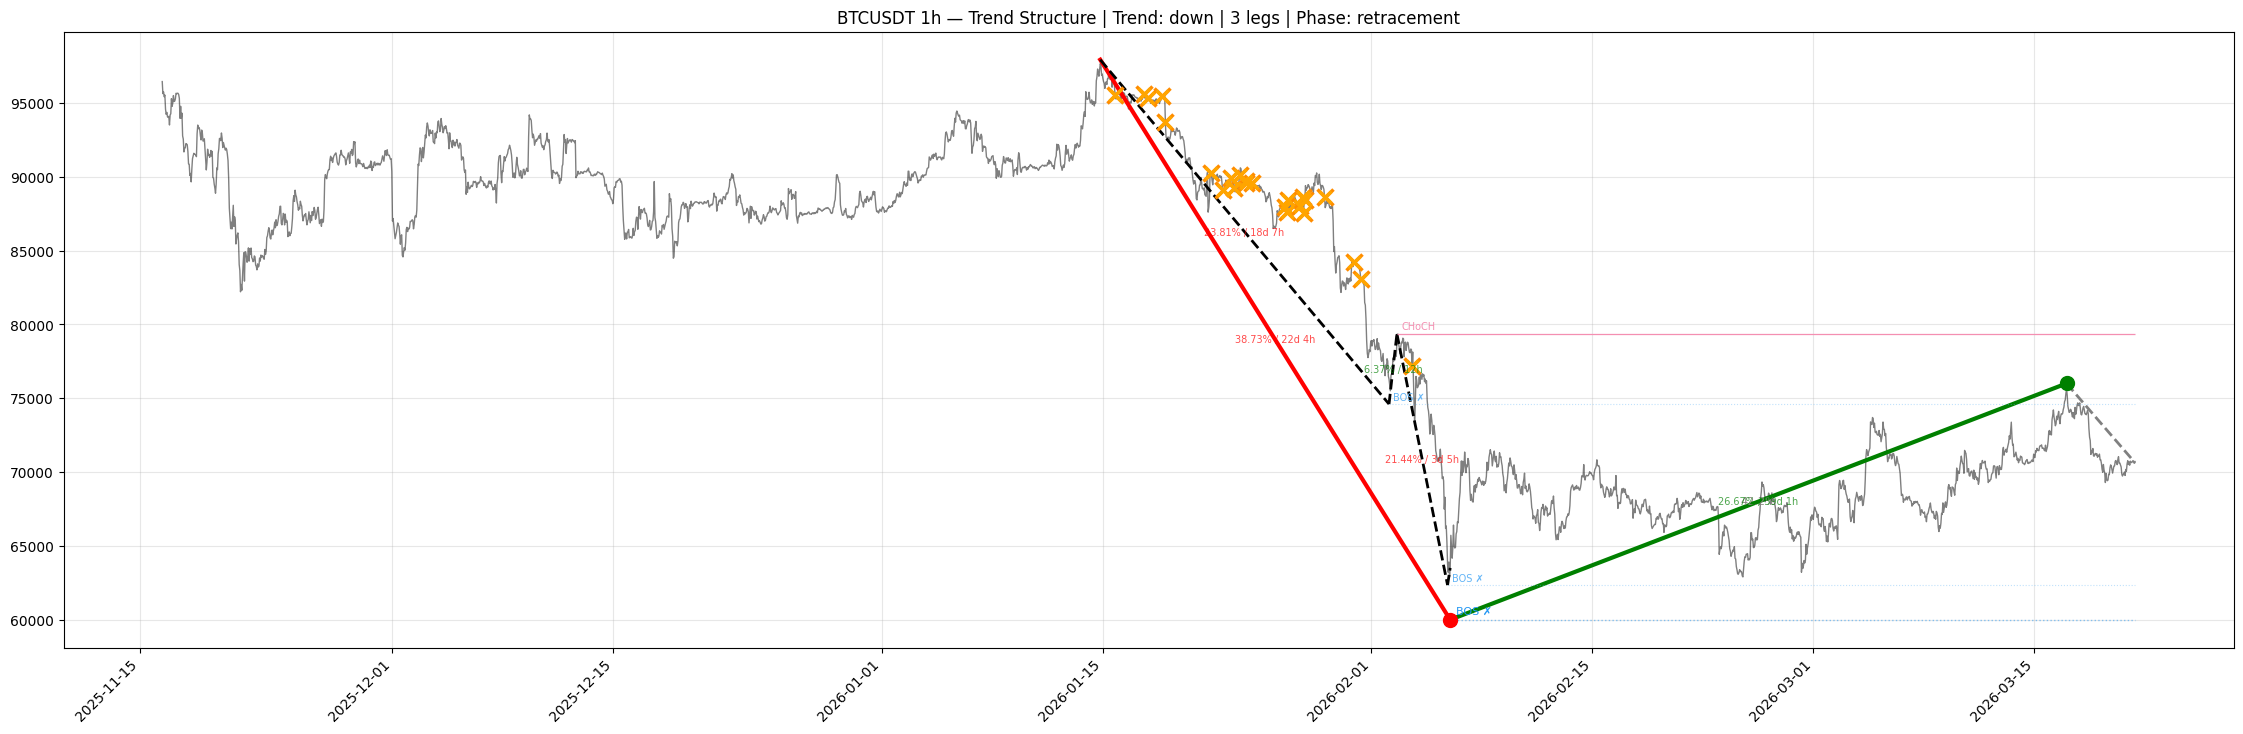

In [5]:
def draw_trend_chart(candles, result, title, use_datetime_axis=False, figsize=(28, 8)):
    display = candles

    _, ax = plt.subplots(figsize=figsize)

    x_values = [c.timestamp for c in display] if use_datetime_axis else list(range(len(display)))

    # Plot closing prices as a simple line for visibility
    prices = [c.close for c in display]
    ax.plot(x_values, prices, color='black', alpha=0.5, linewidth=1)

    def x_at(index):
        return display[index].timestamp if use_datetime_axis else index

    def diff_sign(value):
        if value > 0:
            return 1
        if value < 0:
            return -1
        return 0

    chart_end_x = x_at(len(candles) - 1)

    # Draw outer legs
    for leg in result["legs"]:
        start_idx = leg["start_index"]
        end_idx = leg["end_index"] if leg["end_index"] is not None else len(display) - 1

        start_x = x_at(start_idx)
        end_x = x_at(end_idx)

        start_y = leg["start_price"]
        end_y = leg["end_price"] if leg["end_price"] is not None else display[-1].close

        if result["trend"] == "down":
            color = "red" if leg["type"] == "impulse" else "green"
        else:
            color = "green" if leg["type"] == "impulse" else "red"

        if not leg["confirmed"]:
            ax.plot([start_x, end_x], [start_y, end_y], color='grey', linestyle='--', linewidth=2)
        else:
            ax.plot([start_x, end_x], [start_y, end_y], color=color, linewidth=3)
            ax.scatter(end_x, end_y, color=color, s=100, zorder=5)

    # Draw internal structure only within the parent impulse span.
    for leg in result["legs"]:
        internal = leg.get("internal_structure")
        parent_start = leg["start_index"]
        parent_end = leg["end_index"]

        if internal is None or parent_end is None:
            continue

        for internal_leg in internal["legs"]:
            relative_start = internal_leg["start_index"]
            relative_end = internal_leg["end_index"] if internal_leg["end_index"] is not None else parent_end - parent_start

            start_idx = parent_start + relative_start
            end_idx = parent_start + relative_end
            end_idx = min(end_idx, parent_end)

            start_x = x_at(start_idx)
            end_x = x_at(end_idx)

            start_y = internal_leg["start_price"]
            if internal_leg["end_price"] is not None:
                end_y = internal_leg["end_price"]
            else:
                end_y = display[end_idx].close

            ax.plot([start_x, end_x], [start_y, end_y], color='black', linestyle='--', linewidth=2)

    def annotate_retracement_depth_label(leg, index_offset=0, max_end_index=None):
        depth = leg.get("retracement_depth")
        if depth is None:
            return
        if leg.get("type") != "retracement" or leg.get("confirmed") is not True:
            return
        if leg.get("start_index") is None or leg.get("end_index") is None:
            return

        start_index = leg["start_index"] + index_offset
        end_index = leg["end_index"] + index_offset
        if max_end_index is not None:
            end_index = min(end_index, max_end_index)

        mid_index = (start_index + end_index) // 2
        start_price = float(leg["start_price"])
        end_price = float(leg["end_price"])
        mid_price = (start_price + end_price) / 2.0
        ax.text(
            x_at(mid_index),
            mid_price,
            f"{depth['depth_pct']}%",
            fontsize=8,
            color="#888780",
            ha="center",
            va="center",
            zorder=8,
        )

    def annotate_leg_metrics_label(leg, index_offset=0, max_end_index=None):
        metrics = leg.get("metrics")
        if metrics is None:
            return
        if leg.get("confirmed") is not True:
            return
        if leg.get("start_index") is None or leg.get("end_index") is None:
            return

        start_index = leg["start_index"] + index_offset
        end_index = leg["end_index"] + index_offset
        if max_end_index is not None:
            end_index = min(end_index, max_end_index)

        mid_index = (start_index + end_index) // 2
        start_price = float(leg["start_price"])
        end_price = float(leg["end_price"]) if leg["end_price"] is not None else display[end_index].close
        mid_price = (start_price + end_price) / 2.0

        price_move = metrics.get("price_move_pct")
        duration_human = metrics.get("duration_human")
        if price_move is None or duration_human is None:
            return

        label = f"{abs(price_move):.2f}% / {duration_human}"
        color = "red" if leg["type"] == "impulse" else "green"
        if result["trend"] == "up":
            color = "green" if leg["type"] == "impulse" else "red"

        ax.text(
            x_at(mid_index),
            mid_price,
            label,
            fontsize=7,
            color=color,
            ha="center" ,
            va="center" ,
            alpha=0.7,
            zorder=9,
        )

    for leg in result["legs"]:
        annotate_retracement_depth_label(leg)
        annotate_leg_metrics_label(leg)

    for parent_leg in result["legs"]:
        internal = parent_leg.get("internal_structure")
        if (
            internal is None
            or parent_leg.get("start_index") is None
            or parent_leg.get("end_index") is None
        ):
            continue

        parent_start = parent_leg["start_index"]
        parent_end = parent_leg["end_index"]
        for internal_leg in internal["legs"]:
            annotate_retracement_depth_label(
                internal_leg,
                index_offset=parent_start,
                max_end_index=parent_end,
            )
            annotate_leg_metrics_label(
                internal_leg,
                index_offset=parent_start,
                max_end_index=parent_end,
            )

    ema9 = compute_ema(display, 9)
    ema21 = compute_ema(display, 21)
    crossover_indices = []
    for index in range(1, len(display)):
        previous_ema9 = ema9[index - 1]
        previous_ema21 = ema21[index - 1]
        current_ema9 = ema9[index]
        current_ema21 = ema21[index]
        if (
            previous_ema9 is None
            or previous_ema21 is None
            or current_ema9 is None
            or current_ema21 is None
        ):
            continue

        previous_diff = previous_ema9 - previous_ema21
        current_diff = current_ema9 - current_ema21
        if diff_sign(previous_diff) != diff_sign(current_diff):
            crossover_indices.append(index)

    # Tier 1: keep only crossovers inside confirmed global impulses and
    # suppress any that fall inside confirmed internal retracement zones.
    internal_retracement_indices = set()
    internal_impulse_legs = []

    for leg in result["legs"]:
        if (
            leg.get("type") != "impulse"
            or leg.get("confirmed") is not True
            or leg.get("start_index") is None
            or leg.get("end_index") is None
        ):
            continue

        internal = leg.get("internal_structure")
        if internal is None:
            continue

        parent_start = leg["start_index"]
        parent_end = leg["end_index"]

        for internal_leg in internal["legs"]:
            if (
                internal_leg.get("confirmed") is not True
                or internal_leg.get("start_index") is None
                or internal_leg.get("end_index") is None
            ):
                continue

            global_start = parent_start + internal_leg["start_index"]
            global_end = min(parent_start + internal_leg["end_index"], parent_end)

            if internal_leg.get("type") == "retracement":
                for retrace_index in range(global_start, global_end + 1):
                    internal_retracement_indices.add(retrace_index)
            elif internal_leg.get("type") == "impulse":
                internal_impulse_legs.append(
                    {
                        "type": "impulse",
                        "confirmed": True,
                        "start_index": global_start,
                        "end_index": global_end,
                    }
                )

    global_crossover_indices = set(
        filter_crossovers_in_impulses(
            crossover_indices,
            result["legs"],
            suppress_indices=internal_retracement_indices,
        )
    )

    # Tier 2: local markers only inside confirmed internal impulse legs.
    internal_crossover_indices = set(
        filter_crossovers_in_impulses(crossover_indices, internal_impulse_legs)
    )

    for index in sorted(global_crossover_indices):
        ax.plot(
            [x_at(index)],
            [display[index].close],
            marker='x',
            linestyle='None',
            color='#FF8C00',
            markersize=12,
            markeredgewidth=2.5,
            zorder=5,
        )

    for index in sorted(internal_crossover_indices):
        ax.plot(
            [x_at(index)],
            [display[index].close],
            marker='x',
            linestyle='None',
            color='#FFA500',
            markersize=8,
            markeredgewidth=2.5,
            zorder=6,
        )

    # Add global BOS and CHoCH horizontal structure levels.
    levels = compute_all_structure_levels(candles, result["legs"], result["trend"])
    bos_levels = levels["bos_levels"]

    for bos in bos_levels:
        print(f"BOS | price={bos['price']:.2f} | start={bos['start_index']} ({x_at(bos['start_index'])}) | end={bos['end_index']} ({x_at(bos['end_index'])}) | broken={bos['broken']}")

    for bos in bos_levels:
        bos_start_x = x_at(bos["start_index"])
        bos_label = "BOS ✗" if bos["broken"] else "BOS"
        bos_linewidth = 1.0 if bos["broken"] else 1.5
        bos_linestyle = ":" if bos["broken"] else "--"
        bos_alpha = 0.5 if bos["broken"] else 1.0
        ax.hlines(
            y=bos["price"],
            xmin=bos_start_x,
            xmax=chart_end_x,
            colors="#2196F3",
            linewidth=bos_linewidth,
            linestyles=bos_linestyle,
            alpha=bos_alpha,
            zorder=3,
        )
        ax.annotate(
            bos_label,
            xy=(bos_start_x, bos["price"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            color="#2196F3",
        )

    choch = levels["choch_level"]
    if choch is not None:
        choch_start_x = x_at(choch["start_index"])
        choch_label = "CHoCH ✗" if choch["broken"] else "CHoCH"
        choch_linewidth = 1.0 if choch["broken"] else 1.5
        choch_linestyle = ":" if choch["broken"] else "-"
        choch_alpha = 0.5 if choch["broken"] else 1.0
        ax.hlines(
            y=choch["price"],
            xmin=choch_start_x,
            xmax=chart_end_x,
            colors="#E91E63",
            linewidth=choch_linewidth,
            linestyles=choch_linestyle,
            alpha=choch_alpha,
            zorder=4,
        )
        ax.annotate(
            choch_label,
            xy=(choch_start_x, choch["price"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            color="#E91E63",
        )

    # Add internal BOS and CHoCH levels in lighter dotted styles.
    for leg in result["legs"]:
        internal_bos_levels = leg.get("internal_bos_levels") or []
        for bos in internal_bos_levels:
            bos_start_x = x_at(bos["start_index"])
            bos_label = "BOS ✗" if bos["broken"] else "BOS"
            bos_linewidth = 0.8 if bos["broken"] else 0.9
            bos_linestyle = ":" if bos["broken"] else "--"
            bos_alpha = 0.4 if bos["broken"] else 1.0
            ax.hlines(
                y=bos["price"],
                xmin=bos_start_x,
                xmax=chart_end_x,
                colors="#64B5F6",
                linewidth=bos_linewidth,
                linestyles=bos_linestyle,
                alpha=bos_alpha,
                zorder=2,
            )
            ax.annotate(
                bos_label,
                xy=(bos_start_x, bos["price"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=7,
                color="#64B5F6",
            )

        internal_choch = leg.get("internal_choch_level")
        if internal_choch is not None:
            choch_start_x = x_at(internal_choch["start_index"])
            choch_label = "CHoCH ✗" if internal_choch["broken"] else "CHoCH"
            choch_linewidth = 0.8 if internal_choch["broken"] else 0.9
            choch_linestyle = ":" if internal_choch["broken"] else "-"
            choch_alpha = 0.4 if internal_choch["broken"] else 1.0
            ax.hlines(
                y=internal_choch["price"],
                xmin=choch_start_x,
                xmax=chart_end_x,
                colors="#F48FB1",
                linewidth=choch_linewidth,
                linestyles=choch_linestyle,
                alpha=choch_alpha,
                zorder=2,
            )
            ax.annotate(
                choch_label,
                xy=(choch_start_x, internal_choch["price"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=7,
                color="#F48FB1",
            )

    if use_datetime_axis:
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    else:
        tick_step = max(1, len(display) // 20)
        tick_pos = list(range(0, len(display), tick_step))
        tick_lbl = [display[i].timestamp.strftime("%b %d\n%H:%M") for i in tick_pos]

        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lbl, fontsize=7, rotation=45)

    ax.set_title(f"{title} | Trend: {result['trend']} | {len(result['legs'])} legs | Phase: {result['current_phase']}")
    ax.grid(True, alpha=0.3)
    plt.show()

# Run the chart
draw_trend_chart(
    candles,
    result,
    chart_title,
    use_datetime_axis=(active_data_source == "binance"),
)


BOS | price=68793.35 | start=2495 (2026-03-19 15:45:00+00:00) | end=2999 (2026-03-21 09:45:00+00:00) | broken=True


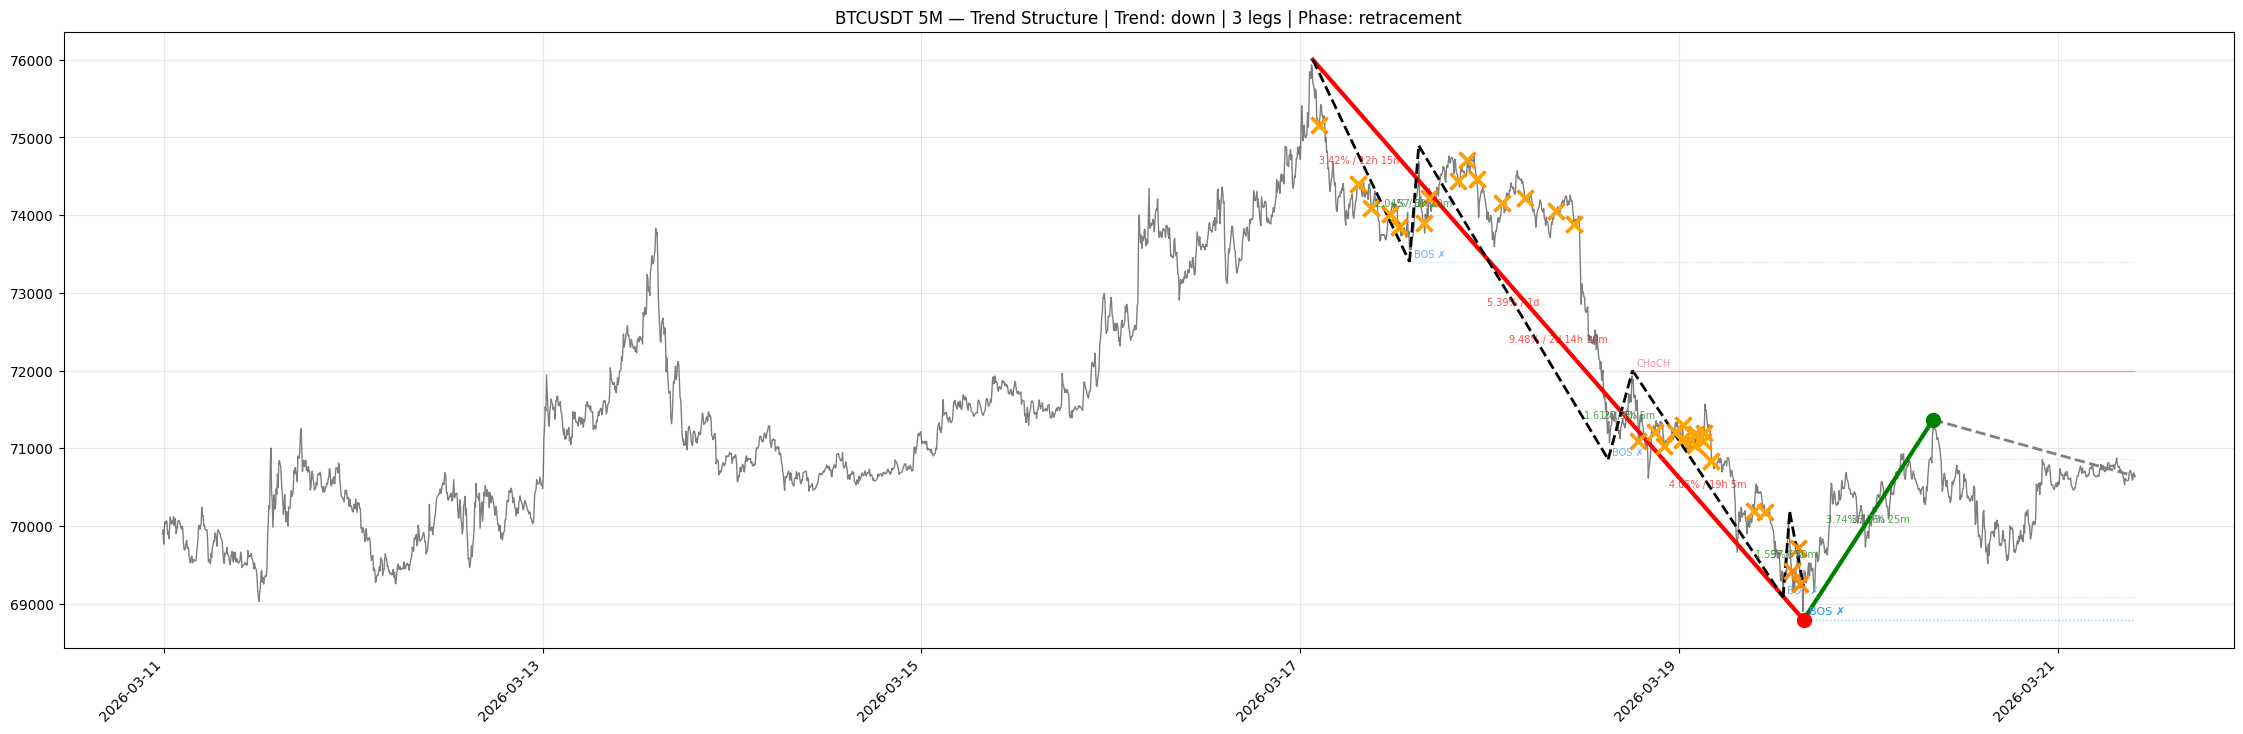

BTCUSDT 5M — Trend Structure | candles=3000 | range=2026-03-10 23:50:00+00:00 -> 2026-03-21 09:45:00+00:00 | trend=down | confirmed_legs=2 | phase=retracement
BOS | price=74050.00 | start=1405 (2026-03-04 19:15:00+00:00) | end=2999 (2026-03-21 09:45:00+00:00) | broken=True


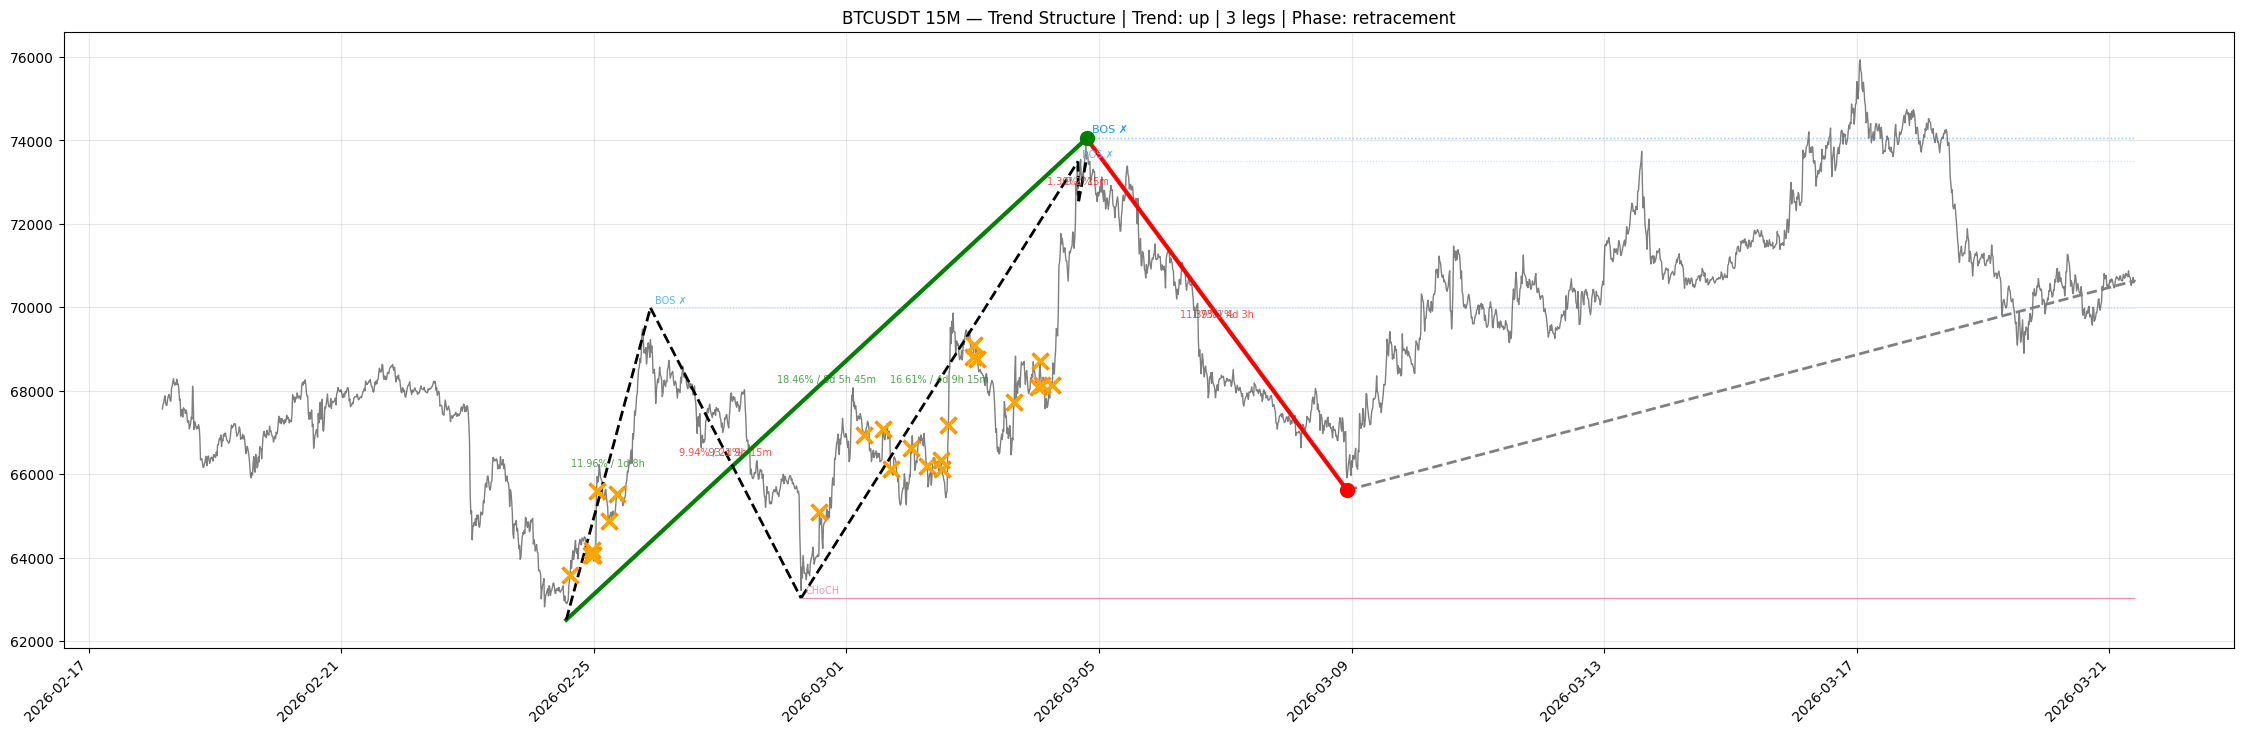

BTCUSDT 15M — Trend Structure | candles=3000 | range=2026-02-18 04:00:00+00:00 -> 2026-03-21 09:45:00+00:00 | trend=up | confirmed_legs=2 | phase=retracement
BOS | price=60000.00 | start=1958 (2026-02-06 00:00:00+00:00) | end=2999 (2026-03-21 09:00:00+00:00) | broken=True


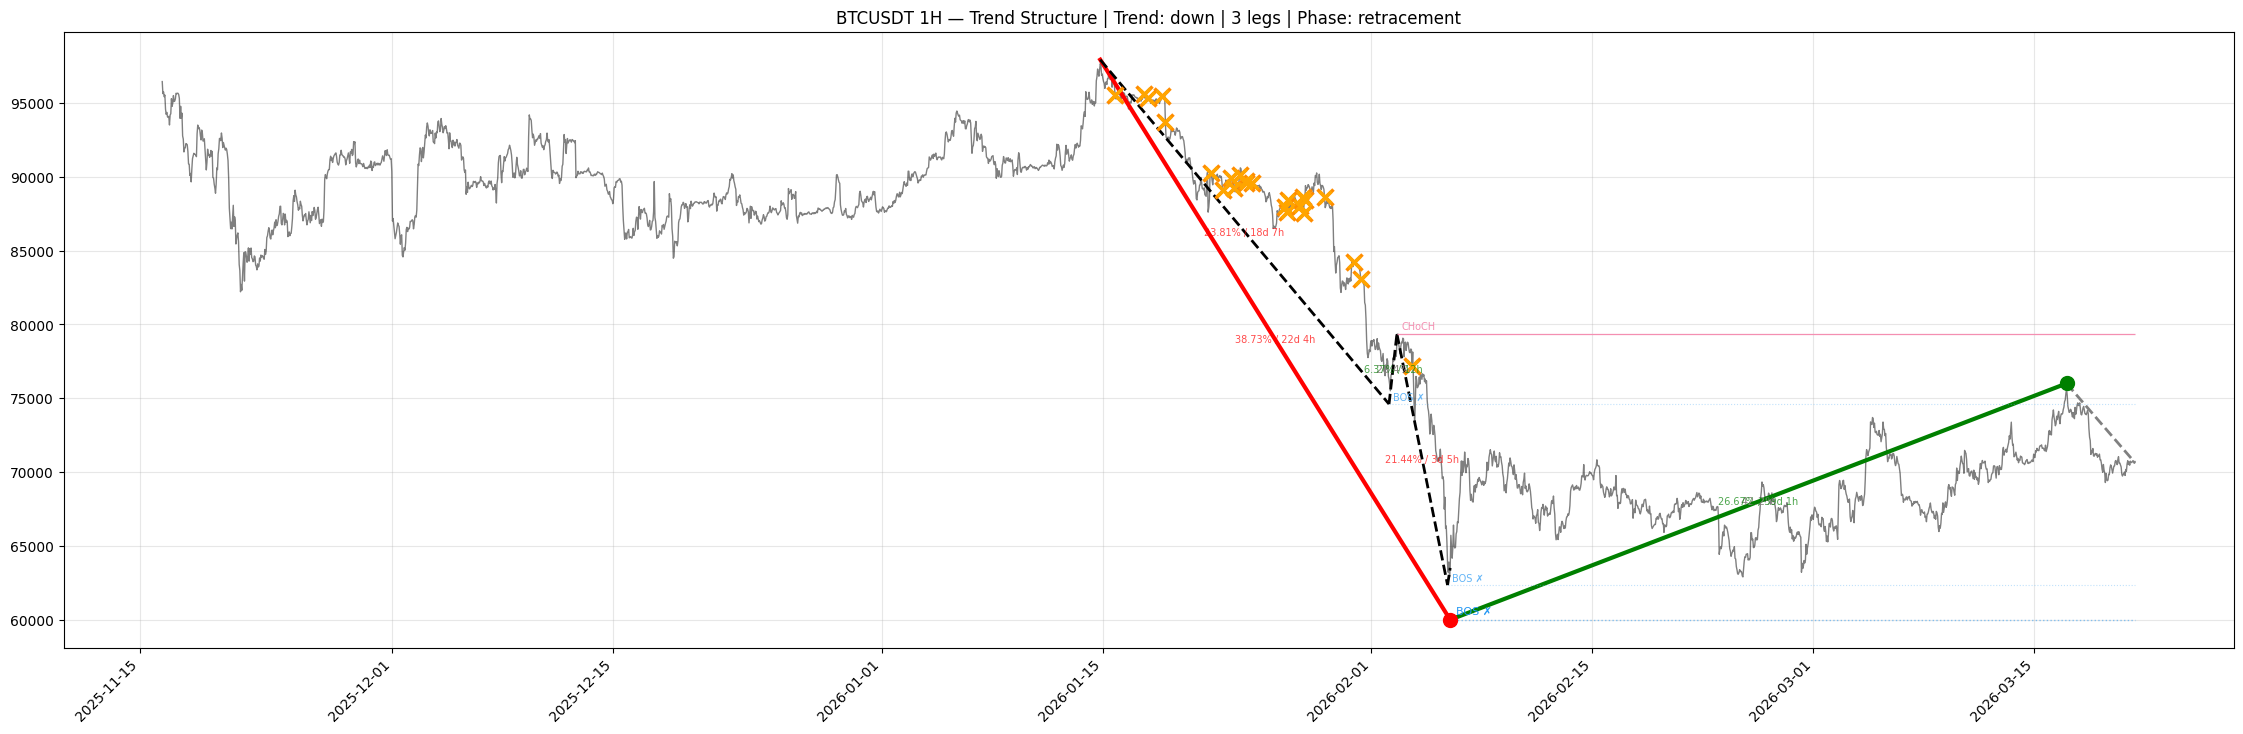

BTCUSDT 1H — Trend Structure | candles=3000 | range=2025-11-16 10:00:00+00:00 -> 2026-03-21 09:00:00+00:00 | trend=down | confirmed_legs=2 | phase=retracement
BOS | price=80600.00 | start=2280 (2025-11-21 12:00:00+00:00) | end=2999 (2026-03-21 08:00:00+00:00) | broken=True
BOS | price=60000.00 | start=2739 (2026-02-06 00:00:00+00:00) | end=2999 (2026-03-21 08:00:00+00:00) | broken=True


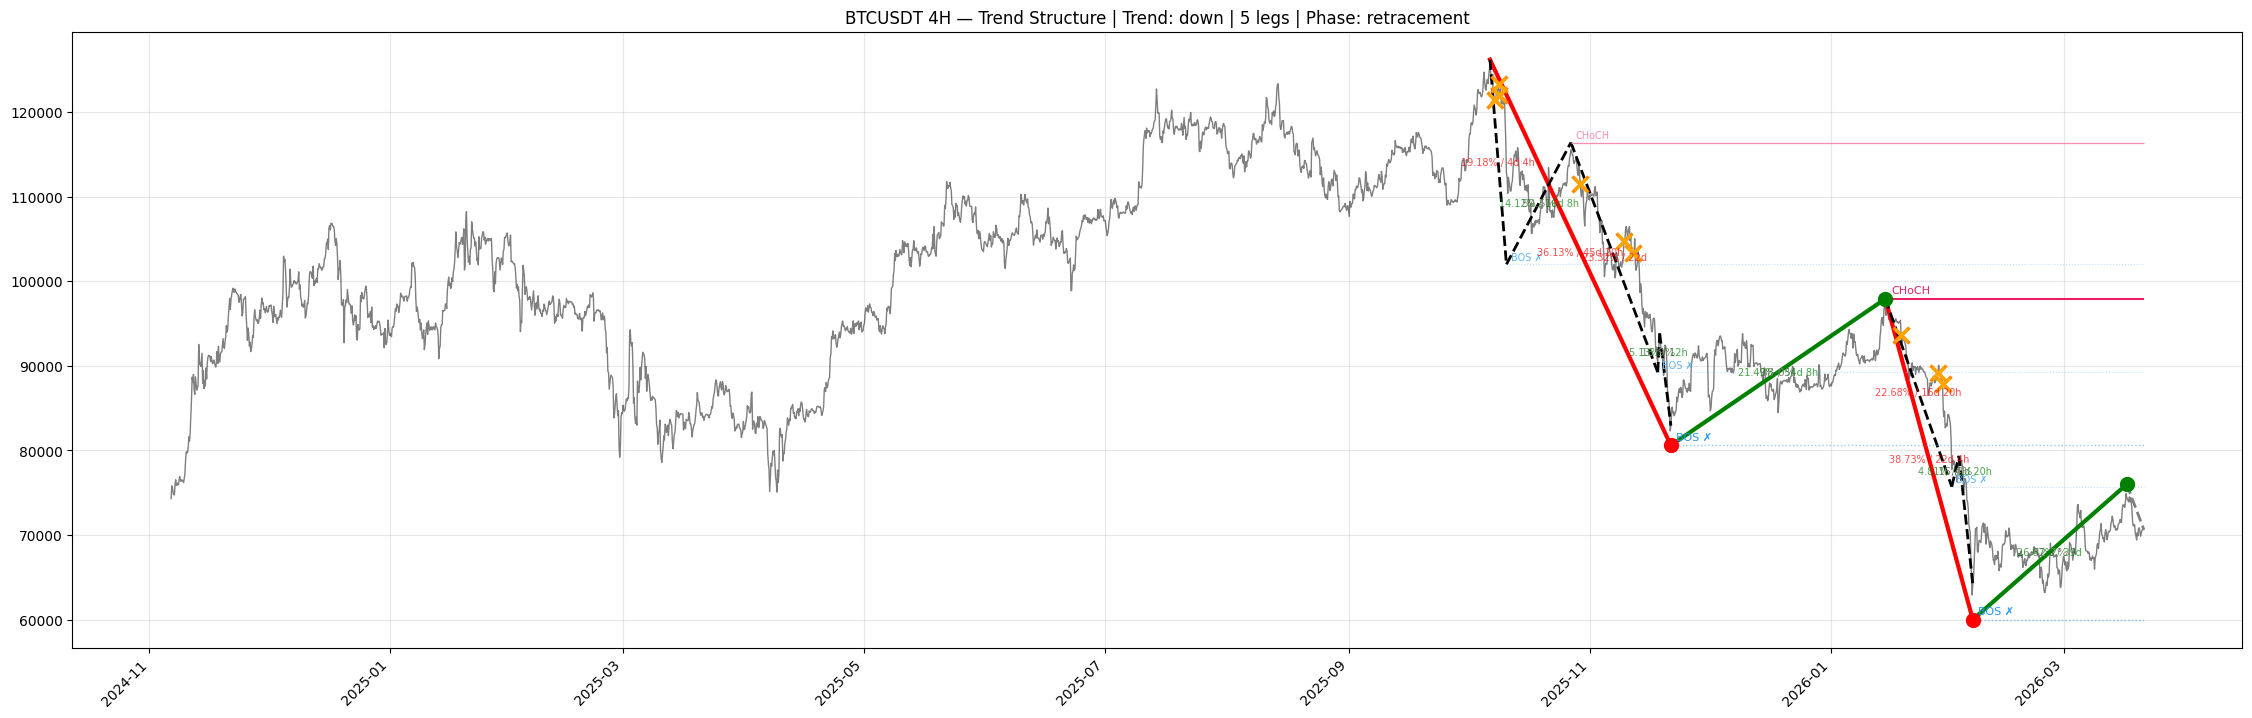

BTCUSDT 4H — Trend Structure | candles=3000 | range=2024-11-06 12:00:00+00:00 -> 2026-03-21 08:00:00+00:00 | trend=down | confirmed_legs=4 | phase=retracement


In [6]:
# Multi-timeframe trend structure plots (additive: keeps single-chart cells untouched).
import asyncio
from src.adapters.binance_data import fetch_binance_ohlc_sync
from src.core.leg_metrics import annotate_legs_with_metrics

local_timeframe_files = {
    "1m": "R_10_1m.csv",
    "5m": "R_10_5m.csv",
    "15m": "R_10_15m.csv",
    "1h": "R_10_1H.csv",
    "4h": "R_10_4H.csv",
    "1d": "R_10_D.csv",
}

for tf in TIMEFRAMES_TO_PLOT:
    tf_key = tf.lower()
    tf_candles = None

    if DATA_SOURCE == "binance":
        try:
            # In a notebook kernel, prefer async call to avoid asyncio.run() conflicts.
            asyncio.get_running_loop()
            tf_candles = await fetch_binance_ohlc(BINANCE_SYMBOL, tf_key)
        except RuntimeError:
            # Outside notebook event loops, use the requested sync API.
            try:
                tf_candles = fetch_binance_ohlc_sync(BINANCE_SYMBOL, tf_key)
            except Exception as exc:
                print(f"[WARN] Binance fetch failed for {BINANCE_SYMBOL} {tf_key}: {exc}")
                continue
        except Exception as exc:
            print(f"[WARN] Binance fetch failed for {BINANCE_SYMBOL} {tf_key}: {exc}")
            continue
    else:
        filename = local_timeframe_files.get(tf_key)
        if filename is None:
            print(f"[WARN] Local timeframe '{tf}' is not supported. Skipping.")
            continue

        local_path = ROOT / "data" / "processed" / filename
        if not local_path.exists():
            print(f"[WARN] Local data file not found for timeframe '{tf}': {local_path}")
            continue

        tf_candles = load_csv(local_path)
        if tf_key in tf_cfg:
            tf_candles = filter_lookback(tf_candles, tf_key)

    if not tf_candles:
        print(f"[WARN] No candles for timeframe '{tf}'. Skipping.")
        continue

    tf_result = identify_trend(
        tf_candles,
        use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
        min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
        use_momentum_filter=USE_MOMENTUM_FILTER,
        min_momentum_ratio=MIN_MOMENTUM_RATIO,
        use_dominance_filter=USE_DOMINANCE_FILTER,
        min_dominance_ratio=MIN_DOMINANCE_RATIO,
    )

    compute_internal_structure(
        tf_candles,
        tf_result["legs"],
        use_parent_relative_filter=USE_PARENT_RELATIVE_FILTER,
        min_impulse_parent_ratio=MIN_IMPULSE_PARENT_RATIO,
        use_momentum_filter=USE_MOMENTUM_FILTER,
        min_momentum_ratio=MIN_MOMENTUM_RATIO,
        use_dominance_filter=USE_DOMINANCE_FILTER,
        min_dominance_ratio=MIN_DOMINANCE_RATIO,
    )
    compute_internal_structure_levels(tf_candles, tf_result["legs"])
    annotate_legs_with_depth(tf_result["legs"])
    annotate_legs_with_metrics(tf_result["legs"], tf_candles, tf_key, is_synthetic=False)
    for leg in tf_result["legs"]:
        if leg.get("internal_structure") and leg["internal_structure"] is not None:
            annotate_legs_with_depth(leg["internal_structure"]["legs"])

    tf_title = f"{SYMBOL_LABEL} {tf_key.upper()} — Trend Structure"
    draw_trend_chart(
        tf_candles,
        tf_result,
        tf_title,
        use_datetime_axis=(DATA_SOURCE == "binance"),
        figsize=(28, 8),
    )

    confirmed_legs = sum(1 for leg in tf_result["legs"] if leg["confirmed"])
    print(
        f"{tf_title} | candles={len(tf_candles)} | "
        f"range={tf_candles[0].timestamp} -> {tf_candles[-1].timestamp} | "
        f"trend={tf_result['trend']} | confirmed_legs={confirmed_legs} | "
        f"phase={tf_result['current_phase']}"
    )
